# Feature Engineering
Simplify the data into fundamental features

### Feature 1: core frequency

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 344ms/step


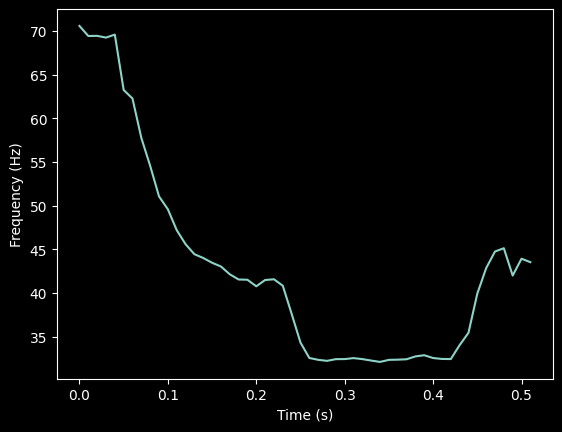

The core frequency is 43.06632351827611 Hz


In [29]:
#!pip install crepe

import crepe
from scipy.io import wavfile

def get_core_frequency(file_path):
    sr, audio = wavfile.read(file_path)
    time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)
    return frequency.mean()

# Example
get_core_frequency('SortedSamples/kicks/ah_kick_gust.wav')

# Plot
plt.plot(time, frequency)
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

print(f'The core frequency is {frequency.mean()} Hz')

### Feature 2: Max Amplitude

The max amplitude is 1793682176


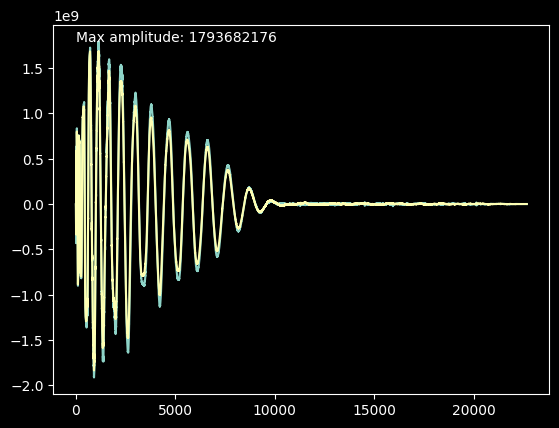

In [30]:
import numpy as np
from scipy.io import wavfile

def get_max_amplitude(file_path):
    sr, audio = wavfile.read(file_path)
    print(f'The max amplitude is {np.max(audio)}')
    return np.max(audio)

get_max_amplitude('SortedSamples/kicks/ah_kick_gust.wav')

# plot the amplitude
plt.plot(audio)
# show the max amplitude on the plot
plt.text(0, np.max(audio), f'Max amplitude: {np.max(audio)}')
plt.show()

### Feature 3: Average Activation

The average activation is 0.006699345540255308


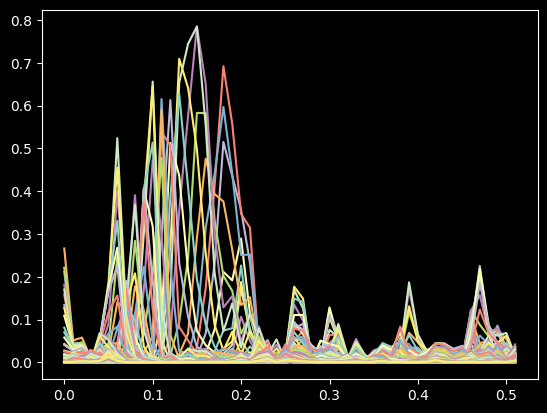

In [ ]:
def get_activation(file_path):
    sr, audio = wavfile.read(file_path)
    time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)
    return activation

# Example
get_activation('SortedSamples/kicks/ah_kick_gust.wav')

# plot activation
plt.plot(time, activation)

# avergae the activation
print(f'The average activation is {activation.mean()}')

### Feature 4: Time

In [31]:
def get_sample_duration(file_path):
    sr, audio = wavfile.read(file_path)
    return len(audio) / sr

# Example
get_sample_duration('SortedSamples/kicks/ah_kick_gust.wav')

print(f'The duration of the sample is {get_sample_duration("SortedSamples/kicks/ah_kick_gust.wav")} seconds')

The duration of the sample is 0.513968253968254 seconds


### Process Wav to Spectogram (Not using atm)

In [2]:
# !pip install librosa
import os
import librosa
import numpy as np

import matplotlib.pyplot as plt

def wav_to_spectrogram(file_path, output_path):
    # Load the audio file
    y, sr = librosa.load(file_path, sr=None)
    
    # Compute the spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_DB = librosa.power_to_db(S, ref=np.max)
    
    # Save the spectrogram as an image
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_DB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel-frequency spectrogram')
    plt.tight_layout()
    plt.savefig(output_path)
    plt.close()

# Directory containing the audio files
input_dir = 'SortedSamples/Kicks'
output_dir = 'Spectrograms/Kicks'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Process each file in the input directory
for file_name in os.listdir(input_dir):
    if file_name.endswith('.wav'):
        input_path = os.path.join(input_dir, file_name)
        output_path = os.path.join(output_dir, file_name.replace('.wav', '.png'))
        wav_to_spectrogram(input_path, output_path)

In [6]:
DATA_PATH = 'SortedSamples'  # Path to your dataset folder
labels = ['claps', 'cymbals', 'hihats', 'kicks', 'percs', 'rides', 'snares', 'toms']